# Model Validation: Actual vs. Predicted Demand
In this notebook, we ignore the external `test.csv` entirely. Instead, we split our `train.csv` into an 80% training set and a 20% validation set. 
This allows us to evaluate the model's accuracy locally and visualize its predictions against the real-world data.

In [1]:
%pip install optuna
%pip install scikit-learn
%pip install lightgbm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
import warnings

warnings.filterwarnings('ignore')
# Set graphing style
sns.set_theme(style="whitegrid")

In [3]:
def load_and_prep_training_data():
    print("Loading training data...")
    train = pd.read_csv('C:/Users/tanay/Documents/gridlock/e88186124ec611f1/dataset/train.csv')
    
    print("Engineering features...")
    # 1. Target Encoding
    geohash_target_mean = train.groupby('geohash')['demand'].mean().reset_index()
    geohash_target_mean.rename(columns={'demand': 'geohash_historical_demand'}, inplace=True)
    train = pd.merge(train, geohash_target_mean, on='geohash', how='left')
    
    # 2. Time Features
    train['hour'] = train['timestamp'].apply(lambda x: int(str(x).split(':')[0]) if pd.notnull(x) else 0)
    train['minute'] = train['timestamp'].apply(lambda x: int(str(x).split(':')[1]) if pd.notnull(x) else 0)
    train.drop('timestamp', axis=1, inplace=True)
    train['is_rush_hour'] = train['hour'].apply(lambda x: 1 if x in [7, 8, 9, 17, 18, 19] else 0)
    
    # 3. Missing Values
    train['RoadType'] = train['RoadType'].fillna('Unknown')
    train['Weather'] = train['Weather'].fillna('Unknown')
    train['Temperature'] = train['Temperature'].fillna(train['Temperature'].median())
    train['NumberofLanes'] = train['NumberofLanes'].fillna(train['NumberofLanes'].mode()[0])
    train['LargeVehicles'] = train['LargeVehicles'].fillna('Unknown')
    train['Landmarks'] = train['Landmarks'].fillna('Unknown')
    
    # 4. Encoding
    cat_cols = ['geohash', 'RoadType', 'LargeVehicles', 'Landmarks', 'Weather']
    for col in cat_cols:
        train[col] = train[col].astype(str)
        le = LabelEncoder()
        train[col] = le.fit_transform(train[col])
        
    X = train.drop(['Index', 'demand'], axis=1)
    y = train['demand']
    
    return X, y

X, y = load_and_prep_training_data()
print("Data ready!")

Loading training data...
Engineering features...
Data ready!


In [4]:
# Create the 80% Train / 20% Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training on {len(X_train)} rows. Testing on {len(X_test)} rows.")

# Use our optimized Phase 2 parameters
best_params = {
    'objective': 'regression',
    'random_state': 42,
    'n_estimators': 220,
    'learning_rate': 0.0860714799646567,
    'num_leaves': 89,
    'max_depth': 7,
    'min_child_samples': 15,
    'subsample': 0.9965483554432846,
    'colsample_bytree': 0.9022918550765342
}

print("Training Model...")
model = lgb.LGBMRegressor(**best_params)
model.fit(X_train, y_train)

# Make predictions on the 20% test set
predictions = model.predict(X_test)
# Prevent negative demand
predictions = np.clip(predictions, a_min=0, a_max=None)

# Calculate Metrics
rmse = np.sqrt(mean_squared_error(y_test, predictions))
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("-" * 30)
print("MODEL EVALUATION SCORES:")
print(f"R-Squared (Accuracy): {r2 * 100:.2f}%")
print(f"Mean Absolute Error:  {mae:.5f}")
print(f"Root Mean Sq Error:   {rmse:.5f}")
print("-" * 30)

Training on 61839 rows. Testing on 15460 rows.
Training Model...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001351 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 816
[LightGBM] [Info] Number of data points in the train set: 61839, number of used features: 12
[LightGBM] [Info] Start training from score 0.093784
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Ligh

  File "c:\Users\tanay\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "c:\Users\tanay\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\tanay\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 556, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\tanay\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 1038, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
            

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

In [5]:
# Create a dataframe to compare side-by-side
results_df = pd.DataFrame({
    'Actual_Demand': y_test.values,
    'Predicted_Demand': predictions,
    'Difference (Error)': np.abs(y_test.values - predictions)
})

# Show the first 15 predictions
display(results_df.head(15))

,Actual_Demand,Predicted_Demand,Difference (Error)
0,0.132365,0.106216,0.026149
1,0.088500,0.077075,0.011425
2,0.032429,0.027484,0.004945
3,0.027974,0.043690,0.015716
4,0.047485,0.079399,0.031914
5,0.043124,0.105956,0.062832
6,0.401779,0.397038,0.004741
7,0.060211,0.088234,0.028023
8,0.109597,0.040584,0.069012
9,0.004044,0.003604,0.000440


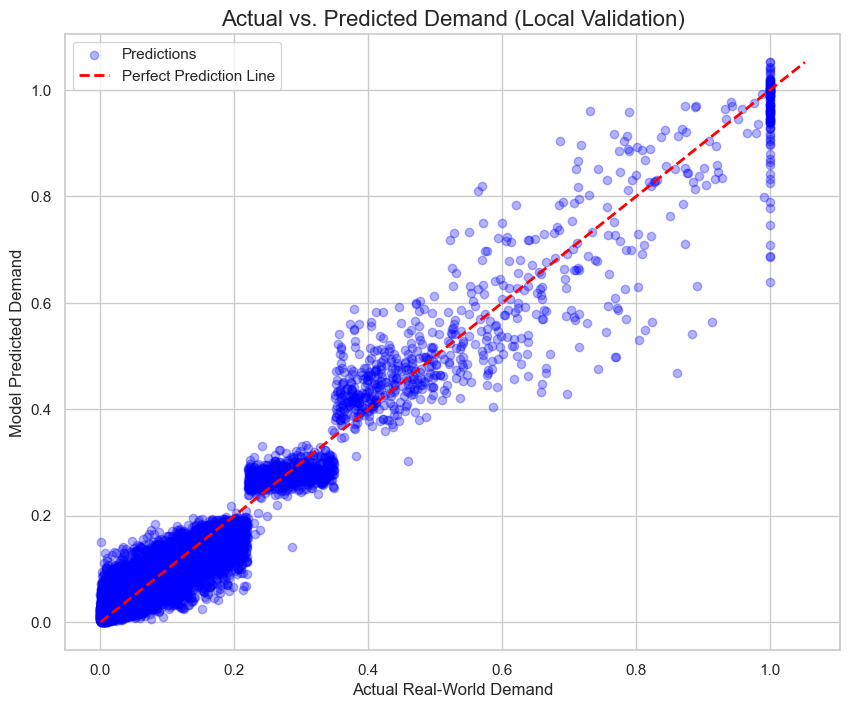

In [6]:
plt.figure(figsize=(10, 8))

# Plot the actual vs predicted points
plt.scatter(y_test, predictions, alpha=0.3, color='blue', label='Predictions')

# Plot the "Perfect Match" diagonal line
max_val = max(y_test.max(), predictions.max())
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction Line')

plt.title('Actual vs. Predicted Demand (Local Validation)', fontsize=16)
plt.xlabel('Actual Real-World Demand', fontsize=12)
plt.ylabel('Model Predicted Demand', fontsize=12)
plt.legend()
plt.show()

In [7]:
# Create a dataframe specifically matching the submission format
local_submission = pd.DataFrame({
    'Index': y_test.index,   # Grabs the original Index numbers from the 20% split
    'demand': predictions    # Your model's predicted demand for those rows
})

# Define the exact path where you want to save it
output_path = 'C:/Users/tanay/Documents/gridlock/e88186124ec611f1/dataset/submission_test_train.csv'

# Export to CSV without the generic pandas index
local_submission.to_csv(output_path, index=False)

print(f"✅ Success! Local validation file saved with {len(local_submission)} rows.")
print(f"Saved to: {output_path}")

# Display the first few rows to verify it looks right!
display(local_submission.head())

✅ Success! Local validation file saved with 15460 rows.
Saved to: C:/Users/tanay/Documents/gridlock/e88186124ec611f1/dataset/submission_test_train.csv


,Index,demand
0,65165,0.106216
1,58878,0.077075
2,6000,0.027484
3,27540,0.043690
4,70232,0.079399
